In [47]:
import sys
sys.path.append("../../../src/")

import numpy as np
from numpy import cos, sin, exp, pi,sqrt
import matplotlib.pyplot as plt
from matplotlib.pyplot import plot, scatter, loglog, xlim, ylim, xlabel, ylabel, loglog, show,legend,yscale,xscale
from time import time


In [118]:
nmax = 18
Ntaus = 50
data_file_name = f"Data/KZ_data_nmax={nmax}_NTaus=_{Ntaus}.npz"

raw_data = np.load(data_file_name)

In [113]:
KZ_array,taus,n_values = raw_data["KZ_Array"],raw_data["taus"],raw_data["n_values"]

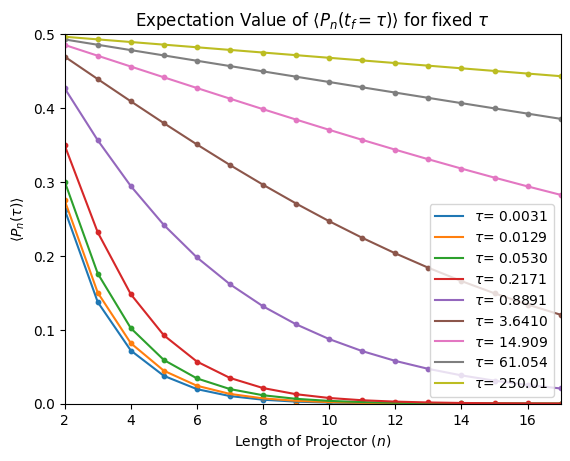

In [124]:
for i in range(0,Ntaus,6):
    plot(n_values,KZ_array[:,i],label=rf"$\tau$= {str(taus[i])[:6]}")
    scatter(n_values,KZ_array[:,i],s=10)

xlim(n_values[0],n_values[-1])
legend()
xlabel(r"Length of Projector ($n$)")
ylabel(r"$\langle P_n (\tau) \rangle$")
plt.title(r"Expectation Value of $\langle P_n (t_f=\tau) \rangle$ for fixed $\tau$")
#yscale("log")
ylim(0,.5)
plt.savefig("Expectation_value_vs_n_and_tau.pdf")

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_22979/2893377707.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_22979/2893377707.py:23: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ylim(0,.5)


(np.float64(9.547085074205764e-06), 0.5)

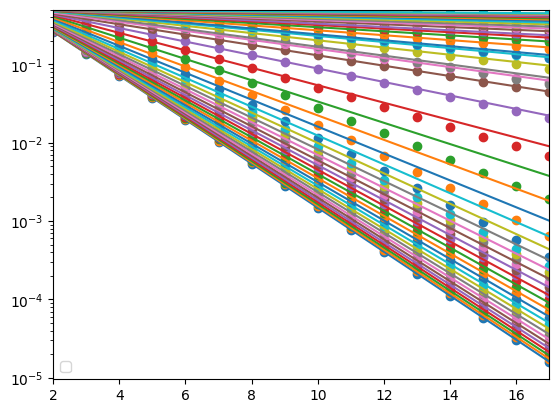

In [120]:
import numpy as np
from scipy.optimize import curve_fit
def exp_model(x, A, b):
    return A * np.exp(-b * x)

Alist= []
Blist = []
for i in range(0,len(taus),1):
    # Example data
    x = np.array(n_values)
    y =KZ_array[:,i]
    # Fit
    popt, pcov = curve_fit(exp_model, x, y, p0=(1, 1))
    A_fit, b_fit = popt
    Alist.append(A_fit)
    Blist.append(b_fit)
    plt.scatter(x,y)
    plt.plot(x,exp_model(x,A_fit,b_fit))
xlim(n_values[0],n_values[-1])

plt.legend()
yscale("log")
ylim(0,.5)


/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_22979/3126638658.py:12: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ylim(0,.75)


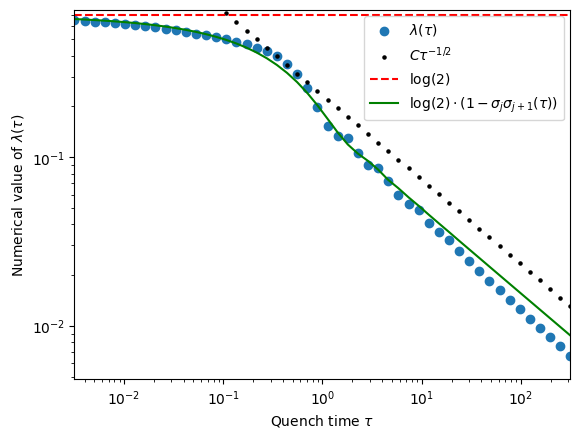

In [176]:
x= 20
scatter(taus,Blist,label=r"$\lambda(\tau)$")
#plot(taus,Alist)
scatter(taus,Blist[x]*taus**(-2/4)/taus[x]**(-2/4),color="black",s=5,label=r"$C \tau^{-1/2}$")

x=1
#plot(taus,Blist[x]*taus**(-1/14)/taus[x]**(-1/14),color="black",ls="--")

xlim(taus[0],taus[-1])
yscale("log")
xscale("log")
ylim(0,.75)
plt.hlines(np.log(2),taus[0],taus[-1],color="red",ls="--",label=r"$\log(2)$")
xlabel(r"Quench time $\tau$")
ylabel(r"Numerical value of $\lambda(\tau)$")
plot(taus,np.log(2)*(1-np.array(dat)),label=r"$ \log(2) \cdot (1-\sigma_j\sigma_{j+1} (\tau))$",color="green")

#scatter(taus,0.5-dat2,label=r"$\delta_4(\tau)$")
#scatter(taus,0.5-np.array(dat3),label=r"$\delta_8(\tau)$")

legend()


In [167]:
import kibble_zurek as kz
from tqdm import tqdm
dat=[]
for tau in tqdm(taus):
    state = kz.state(1000,tau,tau)
    dat.append(kz.sigma_general([0,1],state))



100%|██████████| 50/50 [00:20<00:00,  2.45it/s]


In [148]:
import kibble_zurek as kz
from tqdm import tqdm
dat2=[]
for tau in tqdm(taus):
    state = kz.state(1000,tau,tau)
    dat2.append(kz.P_n(4,state))

dat2=np.array(dat2)

  0%|          | 0/50 [00:00<?, ?it/s]/Users/kristianmunnikhuis/Research Projects/subsystem_loschmidt_echo/scripts/Kibble_Zurek_Scaling/Kibble_Zurek_Scaling_Figures/../../../src/kibble_zurek.py:142: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,state)
100%|██████████| 50/50 [00:20<00:00,  2.47it/s]


In [150]:
import kibble_zurek as kz
from tqdm import tqdm
dat3=[]
for tau in tqdm(taus):
    state = kz.state(1000,tau,tau)
    dat3.append(kz.P_n(8,state))

dat3=np.array(dat3)

  0%|          | 0/50 [00:00<?, ?it/s]/Users/kristianmunnikhuis/Research Projects/subsystem_loschmidt_echo/scripts/Kibble_Zurek_Scaling/Kibble_Zurek_Scaling_Figures/../../../src/kibble_zurek.py:142: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,state)
100%|██████████| 50/50 [00:21<00:00,  2.37it/s]


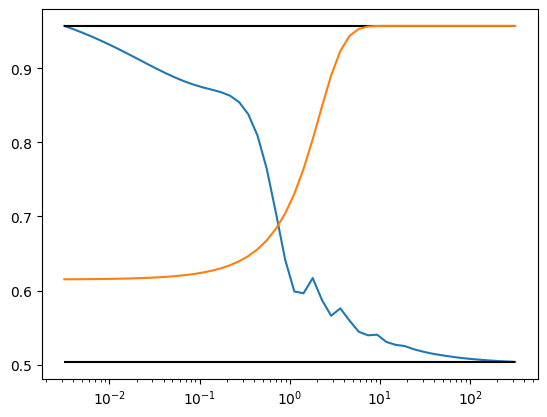

In [182]:
plot(taus,Alist)
x = max(Alist)
y= min(Alist)

xscale("log")
plt.hlines([x,y],taus[0],taus[-1],color="black")
sig = y + (x - y) / (1 + np.exp(-(taus - taus[len(taus)//2])))

plot(taus,sig)

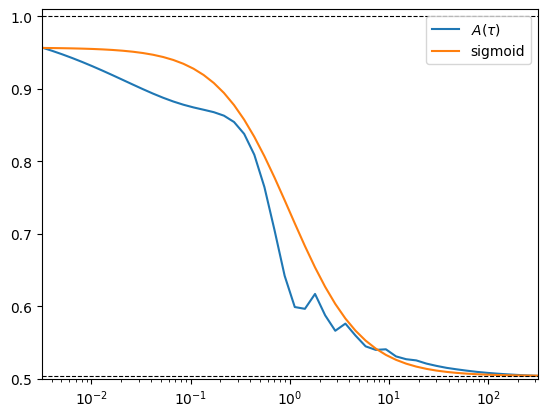

In [223]:
# assumes taus and Alist are already defined

import numpy as np
import matplotlib.pyplot as plt

x = np.max(Alist)   # high
y = np.min(Alist)   # low

t = np.log10(taus)          # log-scale axis
tmin, tmax = t[0], t[-1]

# Constrain logistic in log-space to hug endpoints within eps
eps = 1e-3
zmin = np.log((1 - eps)/eps)
zmax = -zmin

k  = (zmax - zmin) / (tmax - tmin)
t0 = tmin - zmin / k

sigma = 1.0 / (1.0 + np.exp(-k * (t - t0)))  # low→high in log-space
sig   = (x - y) * sigma+x/1.9        # high→low in log-space
plt.xscale("log")
#plt.yscale("log")
plt.ylim(0.5,1.01)
plt.xlim(taus[0],taus[-1])

plt.plot(taus, Alist, label=r"$A(\tau)$")
plt.plot(taus, sig, label="sigmoid")
plt.hlines([1, y], taus[0], taus[-1], color="black", linewidth=0.8,ls="--")
plt.legend()
plt.show()


np.float64(0.957016391953024)